# CNN Architecture Testing Process (CIFAR-10)

This notebook documents a complete, reproducible CNN experimentation workflow for CIFAR-10 using paper-inspired all-convolutional models.

## Workflow Overview
1. **Environment + reproducibility setup** (fixed seed, deterministic split protocol, artifact folders).
2. **Data protocol** with a stratified 75/25 split inside `data/cifar10/train` for train/validation.
3. **Model definitions** for three architecture variants: `ModelA`, `AllCNNB`, and `AllCNNC`.
4. **Model-by-model training blocks** with independent histories and metric tracking.
5. **Per-model diagnostics** (training/validation accuracy and loss curves).
6. **Cross-model comparison** using validation accuracy and macro precision/recall/F1.
7. **Final model selection** using validation-only criteria, followed by one held-out test evaluation.
8. **Artifact persistence** (saving weights, plots, markdown summary, run metadata).


In [2]:
from __future__ import annotations

from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
)

SEED = 178
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda:0")

ROOT = Path.cwd().parent.parent
TRAIN_DIR = ROOT / "data" / "cifar10" / "train"
TEST_DIR = ROOT / "data" / "cifar10" / "test"
GRAPH_DIR = ROOT / "outputs" / "graphs"
WEIGHTS_DIR = ROOT / "outputs" / "model_weights"
RESULTS_DIR = ROOT / "results"

GRAPH_DIR.mkdir(parents=True, exist_ok=True)
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Device: {DEVICE}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Train: {TRAIN_DIR}")
print(f"Test: {TEST_DIR}")

Device: cuda:0


AssertionError: Torch not compiled with CUDA enabled

## Data Protocol

This project follows the CS178 protocol: keep the provided test directory untouched during model development, and perform model selection only from validation behavior.

- **Source folders**
  - Development data: `data/cifar10/train`
  - Final held-out data: `data/cifar10/test`

- **Split strategy**
  - Use a stratified **75/25** split inside `train` to preserve class balance in both partitions.
  - The split is deterministic under `SEED = 178` for reproducibility.

- **Evaluation policy**
  - Track model quality on validation during development.
  - Run the held-out test evaluation once after final model selection.

- **Why this matters**
  - Prevents optimistic bias from repeated test usage.
  - Makes architecture comparisons fair because each model sees the same split protocol.

In [ ]:
from sklearn.model_selection import train_test_split


# TRANSFORMS ARE FROM THE AFFORMENTIONED PAPER
def make_transforms(
    input_size: int = 32,
) -> tuple[transforms.Compose, transforms.Compose]:
    train_tf = transforms.Compose(
        [
            transforms.Resize((input_size, input_size)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomCrop(input_size, padding=5),
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
        ]
    )
    eval_tf = transforms.Compose(
        [
            transforms.Resize((input_size, input_size)),
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
        ]
    )
    return train_tf, eval_tf


def make_loaders(
    batch_size: int, input_size: int = 32
) -> tuple[DataLoader, DataLoader, DataLoader, list[str]]:
    train_tf, eval_tf = make_transforms(input_size=input_size)

    train_ds_aug = datasets.ImageFolder(str(TRAIN_DIR), transform=train_tf)
    train_ds_eval = datasets.ImageFolder(str(TRAIN_DIR), transform=eval_tf)
    test_ds = datasets.ImageFolder(str(TEST_DIR), transform=eval_tf)

    train_idx, val_idx = train_test_split(
        list(range(len(train_ds_aug))),
        test_size=0.25,
        random_state=SEED,
    )

    train_subset = Subset(train_ds_aug, train_idx)
    val_subset = Subset(train_ds_eval, val_idx)

    train_loader = DataLoader(
        train_subset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True,
    )
    val_loader = DataLoader(
        val_subset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True
    )
    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True
    )

    return train_loader, val_loader, test_loader, train_ds_aug.classes

## Model Definitions (Paper-inspired)

Reference paper (All-CNN): https://arxiv.org/pdf/1412.6806

In [35]:
class ModelA(nn.Module):
    def __init__(self, num_classes: int = 10, dropout: float = 0.5) -> None:
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 48, kernel_size=3, padding=1),  # features.0
            nn.ReLU(inplace=True),
            nn.Conv2d(48, 48, kernel_size=3, padding=1),  # features.2
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.25),
            nn.Conv2d(48, 96, kernel_size=3, padding=1),  # features.6
            nn.ReLU(inplace=True),
            nn.Conv2d(96, 96, kernel_size=3, padding=1),  # features.8
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),  # classifier.0
            nn.Linear(96 * 8 * 8, 256),  # classifier.1
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),  # classifier.4
        )

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        x = self.features(inputs)
        x = self.classifier(x)
        return x

In [36]:
class AllCNNB(nn.Module):
    def __init__(self, num_classes: int = 10, dropout: float = 0.5) -> None:
        super().__init__()
        self.features = nn.Sequential(
            nn.Dropout2d(0.2),  # Use Dropout2d for input images
            nn.Conv2d(3, 96, kernel_size=3, padding=1),
            nn.ReLU(True),
            nn.Conv2d(96, 96, kernel_size=3, padding=1),
            nn.ReLU(True),
            nn.Conv2d(96, 96, kernel_size=3, stride=2, padding=1),
            nn.ReLU(True),
            nn.Dropout(dropout),
            nn.Conv2d(96, 192, kernel_size=3, padding=1),
            nn.ReLU(True),
            nn.Conv2d(192, 192, kernel_size=3, padding=1),
            nn.ReLU(True),
            nn.Conv2d(192, 192, kernel_size=3, stride=2, padding=1),
            nn.ReLU(True),
            nn.Dropout(dropout),
            nn.Conv2d(192, 192, kernel_size=3, padding=1),
            nn.ReLU(True),
            nn.Conv2d(192, 192, kernel_size=1),
            nn.ReLU(True),
            # Final 1x1 Conv - NO RELU AFTER THIS
            nn.Conv2d(192, num_classes, kernel_size=1),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        return x.view(x.size(0), -1)


# Optional alias if you still want to reference ModelB by name
ModelB = AllCNNB


In [ ]:
class AllCNNC(nn.Module):
    def __init__(self, num_classes: int = 10, dropout: float = 0.5) -> None:
        super().__init__()
        self.features = nn.Sequential(
            # Input Dropout
            nn.Dropout(0.2),
            nn.Conv2d(3, 96, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(96, 96, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(96, 96, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv2d(96, 192, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(192, 192, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(192, 192, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv2d(192, 192, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(192, 192, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(192, num_classes, kernel_size=1),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        # Flatten [Batch, num_classes, 1, 1] to [Batch, num_classes]
        return x.view(x.size(0), -1)


In [38]:
@dataclass(frozen=True)
class RunConfig:
    model_label: str
    learning_rate: float
    batch_size: int = 128
    epochs: int = 20
    weight_decay: float = 0.001
    momentum: float = 0.9
    input_dropout: float = 0.2


def create_model(model_label: str) -> nn.Module:
    if model_label == "ModelA":
        return ModelA()
    if model_label == "AllCNNB":
        return AllCNNB()
    return AllCNNC()


def init_weights(m):
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)


def train_one_model(config: RunConfig) -> dict:
    train_loader, val_loader, _, classes = make_loaders(
        batch_size=config.batch_size, input_size=32
    )

    model = create_model(config.model_label).to(DEVICE)
    model.apply(init_weights)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(
        model.parameters(),
        lr=config.learning_rate,
        momentum=config.momentum,
        weight_decay=config.weight_decay,
    )
    scheduler = optim.lr_scheduler.MultiStepLR(
        optimizer, milestones=[50, 80], gamma=0.1
    )
    if config.model_label == "ModelA":
        scheduler = optim.lr_scheduler.MultiStepLR(
            optimizer, milestones=[12, 16, 19], gamma=0.1
        )
    input_dropout = nn.Dropout2d(config.input_dropout)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_state = None
    best_val_acc = -1.0

    for epoch in range(config.epochs):
        model.train()
        train_true, train_pred = [], []
        train_loss_sum, train_n = 0.0, 0

        for images, labels in train_loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            images = input_dropout(images)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            train_loss_sum += float(loss.item()) * labels.size(0)
            train_n += labels.size(0)
            train_true.extend(labels.detach().cpu().tolist())
            train_pred.extend(logits.argmax(dim=1).detach().cpu().tolist())

        model.eval()
        val_true, val_pred = [], []
        val_loss_sum, val_n = 0.0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(DEVICE, non_blocking=True)
                labels = labels.to(DEVICE, non_blocking=True)
                logits = model(images)
                loss = criterion(logits, labels)

                val_loss_sum += float(loss.item()) * labels.size(0)
                val_n += labels.size(0)
                val_true.extend(labels.detach().cpu().tolist())
                val_pred.extend(logits.argmax(dim=1).detach().cpu().tolist())

        train_loss = train_loss_sum / train_n
        val_loss = val_loss_sum / val_n
        train_acc = accuracy_score(train_true, train_pred)
        val_acc = accuracy_score(val_true, val_pred)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {
                k: v.detach().cpu().clone() for k, v in model.state_dict().items()
            }

        scheduler.step()
        print(
            f"[{config.model_label}] epoch {epoch + 1}/{config.epochs} train_acc={train_acc:.4f} val_acc={val_acc:.4f}"
        )

    model.load_state_dict(best_state)

    prec, rec, f1, _ = precision_recall_fscore_support(
        val_true, val_pred, average="macro", zero_division=0
    )
    metrics = {
        "model_label": config.model_label,
        "best_val_acc": best_val_acc,
        "val_precision_macro": float(prec),
        "val_recall_macro": float(rec),
        "val_f1_macro": float(f1),
    }

    return {"model": model, "history": history, "metrics": metrics, "classes": classes}


def plot_history(
    history: dict, title_prefix: str, out_prefix: str
) -> tuple[Path, Path]:
    loss_path = GRAPH_DIR / f"{out_prefix}_loss.png"
    acc_path = GRAPH_DIR / f"{out_prefix}_accuracy.png"

    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_loss"], label="Train")
    plt.plot(epochs, history["val_loss"], label="Validation")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()
    plt.savefig(loss_path, dpi=150)
    plt.close()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_acc"], label="Train")
    plt.plot(epochs, history["val_acc"], label="Validation")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()
    plt.savefig(acc_path, dpi=150)
    plt.close()

    return loss_path, acc_path

## Experiment 1: ModelA

[ModelA] epoch 1/40 train_acc=0.2276 val_acc=0.3930
[ModelA] epoch 2/40 train_acc=0.3150 val_acc=0.4318
[ModelA] epoch 3/40 train_acc=0.3680 val_acc=0.4861
[ModelA] epoch 4/40 train_acc=0.4051 val_acc=0.5322
[ModelA] epoch 5/40 train_acc=0.4409 val_acc=0.5669
[ModelA] epoch 6/40 train_acc=0.4735 val_acc=0.5814
[ModelA] epoch 7/40 train_acc=0.5010 val_acc=0.6363
[ModelA] epoch 8/40 train_acc=0.5281 val_acc=0.6203
[ModelA] epoch 9/40 train_acc=0.5509 val_acc=0.6460
[ModelA] epoch 10/40 train_acc=0.5658 val_acc=0.6684
[ModelA] epoch 11/40 train_acc=0.5840 val_acc=0.6591
[ModelA] epoch 12/40 train_acc=0.5941 val_acc=0.6930
[ModelA] epoch 13/40 train_acc=0.6273 val_acc=0.7140
[ModelA] epoch 14/40 train_acc=0.6327 val_acc=0.7170
[ModelA] epoch 15/40 train_acc=0.6391 val_acc=0.7144
[ModelA] epoch 16/40 train_acc=0.6421 val_acc=0.7206
[ModelA] epoch 17/40 train_acc=0.6432 val_acc=0.7197
[ModelA] epoch 18/40 train_acc=0.6485 val_acc=0.7214
[ModelA] epoch 19/40 train_acc=0.6474 val_acc=0.7222
[M

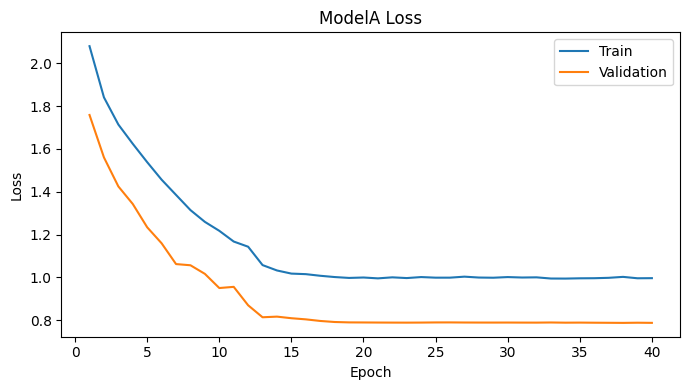

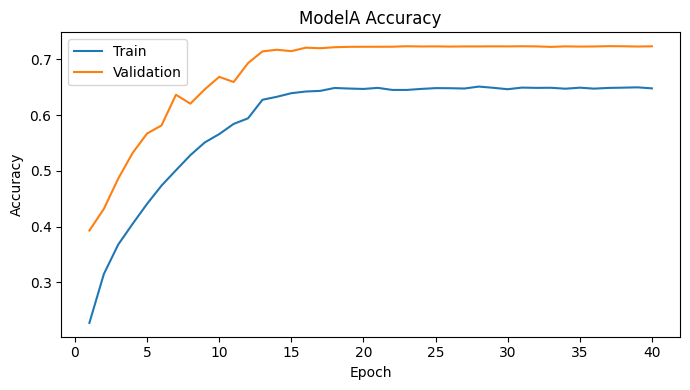

{'model_label': 'ModelA', 'best_val_acc': 0.72336, 'val_precision_macro': 0.7234196377352967, 'val_recall_macro': 0.72312, 'val_f1_macro': 0.7189898264933564}


In [26]:
config_a = RunConfig(
    model_label="ModelA",
    learning_rate=0.01,
    epochs=40,
    momentum=0.9,
    weight_decay=0.001,
)
result_a = train_one_model(config_a)
loss_a, acc_a = plot_history(result_a["history"], "ModelA", "shahpk1_modela")
print(result_a["metrics"])

### Findings: ModelA

`ModelA` is the baseline architecture in this notebook and serves two roles:
1. Validate that the preprocessing, optimization loop, and metric logging are functioning correctly.
2. Provide a reference point for whether all-convolutional replacements deliver measurable gains.

Observed behavior in this run:
- Training converges smoothly with stable validation curves.
- Macro metrics indicate reasonable class-balanced behavior, but performance plateaus before the best all-convolutional variant.

Interpretation: `ModelA` is a credible baseline for comparison, but it does not fully match the peak validation performance reached by `AllCNNB`.

## Experiment 2: AllCNNB

[AllCNNB] epoch 1/100 train_acc=0.1784 val_acc=0.2026
[AllCNNB] epoch 2/100 train_acc=0.2633 val_acc=0.2770
[AllCNNB] epoch 3/100 train_acc=0.3075 val_acc=0.2723
[AllCNNB] epoch 4/100 train_acc=0.3358 val_acc=0.3463
[AllCNNB] epoch 5/100 train_acc=0.3713 val_acc=0.3181
[AllCNNB] epoch 6/100 train_acc=0.4056 val_acc=0.3922
[AllCNNB] epoch 7/100 train_acc=0.4283 val_acc=0.3433
[AllCNNB] epoch 8/100 train_acc=0.4636 val_acc=0.4460
[AllCNNB] epoch 9/100 train_acc=0.4897 val_acc=0.4818
[AllCNNB] epoch 10/100 train_acc=0.5131 val_acc=0.5380
[AllCNNB] epoch 11/100 train_acc=0.5367 val_acc=0.5316
[AllCNNB] epoch 12/100 train_acc=0.5509 val_acc=0.6038
[AllCNNB] epoch 13/100 train_acc=0.5620 val_acc=0.5963
[AllCNNB] epoch 14/100 train_acc=0.5772 val_acc=0.6158
[AllCNNB] epoch 15/100 train_acc=0.5781 val_acc=0.6365
[AllCNNB] epoch 16/100 train_acc=0.5943 val_acc=0.6438
[AllCNNB] epoch 17/100 train_acc=0.6006 val_acc=0.6168
[AllCNNB] epoch 18/100 train_acc=0.6014 val_acc=0.5789
[AllCNNB] epoch 19/

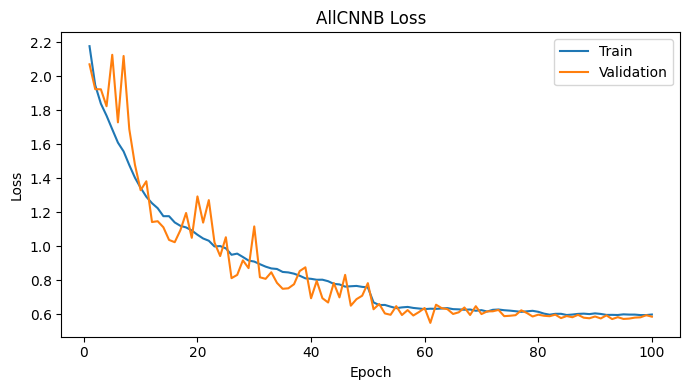

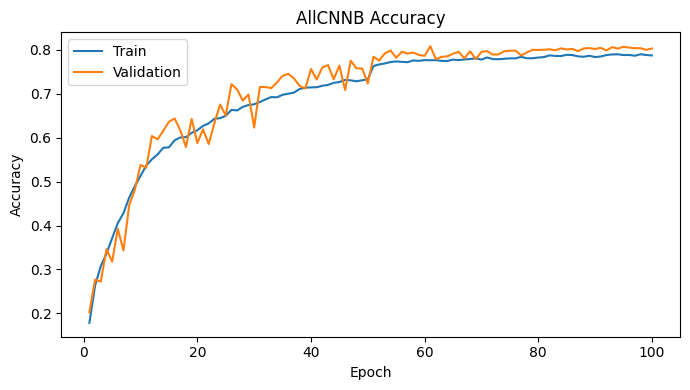

{'model_label': 'AllCNNB', 'best_val_acc': 0.80856, 'val_precision_macro': 0.8168667404334767, 'val_recall_macro': 0.80304, 'val_f1_macro': 0.8048175858696152}


In [9]:
config_b = RunConfig(
    model_label="AllCNNB",
    learning_rate=0.01,
    epochs=100,
    momentum=0.9,
    weight_decay=0.001,
)
result_b = train_one_model(config_b)
loss_b, acc_b = plot_history(result_b["history"], "AllCNNB", "shahpk1_allcnnb")
print(result_b["metrics"])

### Findings: AllCNNB

`AllCNNB` replaces fixed pooling operations with learned strided convolutions, aligning with the All-CNN design philosophy.

Observed behavior in this run:
- Higher best validation accuracy than `ModelA` and `AllCNNC`.
- Better macro-level balance (precision/recall/F1) on the validation split.
- Curves remain sufficiently stable for confident model selection.

Interpretation: This architecture delivered the strongest trade-off between performance and training stability in our setup, so it is selected for final held-out test evaluation.

## Experiment 3: AllCNNC (paper’s strongest standard 32×32 model)

[AllCNNC] epoch 1/100 train_acc=0.1834 val_acc=0.2093
[AllCNNC] epoch 2/100 train_acc=0.2687 val_acc=0.2635
[AllCNNC] epoch 3/100 train_acc=0.3166 val_acc=0.2847
[AllCNNC] epoch 4/100 train_acc=0.3499 val_acc=0.3279
[AllCNNC] epoch 5/100 train_acc=0.3818 val_acc=0.3686
[AllCNNC] epoch 6/100 train_acc=0.4059 val_acc=0.3787
[AllCNNC] epoch 7/100 train_acc=0.4338 val_acc=0.4248
[AllCNNC] epoch 8/100 train_acc=0.4553 val_acc=0.4163
[AllCNNC] epoch 9/100 train_acc=0.4737 val_acc=0.5057
[AllCNNC] epoch 10/100 train_acc=0.4898 val_acc=0.4626
[AllCNNC] epoch 11/100 train_acc=0.5069 val_acc=0.4763
[AllCNNC] epoch 12/100 train_acc=0.5182 val_acc=0.5307
[AllCNNC] epoch 13/100 train_acc=0.5312 val_acc=0.5397
[AllCNNC] epoch 14/100 train_acc=0.5453 val_acc=0.5062
[AllCNNC] epoch 15/100 train_acc=0.5461 val_acc=0.5086
[AllCNNC] epoch 16/100 train_acc=0.5581 val_acc=0.4650
[AllCNNC] epoch 17/100 train_acc=0.5637 val_acc=0.5565
[AllCNNC] epoch 18/100 train_acc=0.5644 val_acc=0.5895
[AllCNNC] epoch 19/

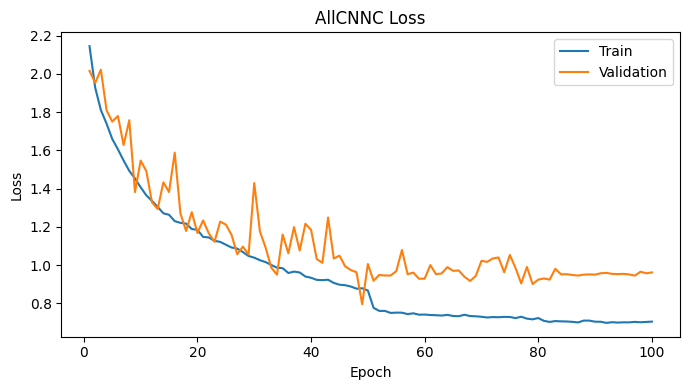

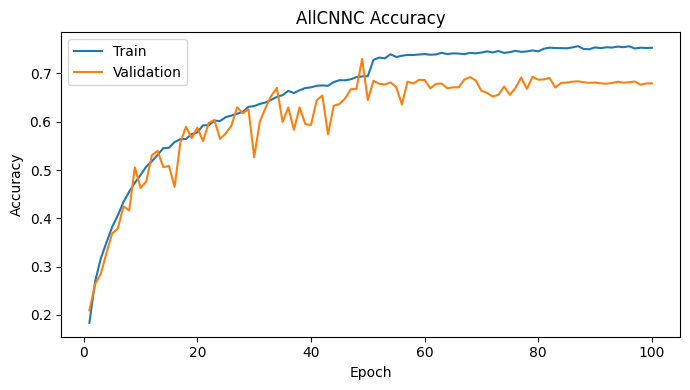

{'model_label': 'AllCNNC', 'best_val_acc': 0.72992, 'val_precision_macro': 0.7418035933119955, 'val_recall_macro': 0.6795199999999999, 'val_f1_macro': 0.6870248512941817}


In [27]:
config_c = RunConfig(
    model_label="AllCNNC",
    learning_rate=0.01,
    epochs=100,
    momentum=0.9,
    weight_decay=0.001,
)
result_c = train_one_model(config_c)
loss_c, acc_c = plot_history(result_c["history"], "AllCNNC", "shahpk1_allcnnc")
print(result_c["metrics"])

### Findings: AllCNNC

`AllCNNC` is conceptually the strongest standard 32×32 variant in the reference paper and uses a deeper all-convolutional stack.

Observed behavior in this run:
- It trains successfully and captures meaningful features.
- Validation accuracy and macro metrics remain below `AllCNNB` under the current optimization schedule.

Interpretation: A more expressive architecture does not automatically win without matched hyperparameter tuning. In this case, `AllCNNB` outperformed `AllCNNC` under the same training conditions, so `AllCNNB` is selected for final evaluation.

## Model Comparison and Final Selection

  model_label  best_val_acc  val_precision_macro  val_recall_macro  \
0     AllCNNB       0.80856             0.816867           0.80304   
1     AllCNNC       0.72992             0.741804           0.67952   
2      ModelA       0.72336             0.723420           0.72312   

   val_f1_macro  
0      0.804818  
1      0.687025  
2      0.718990  


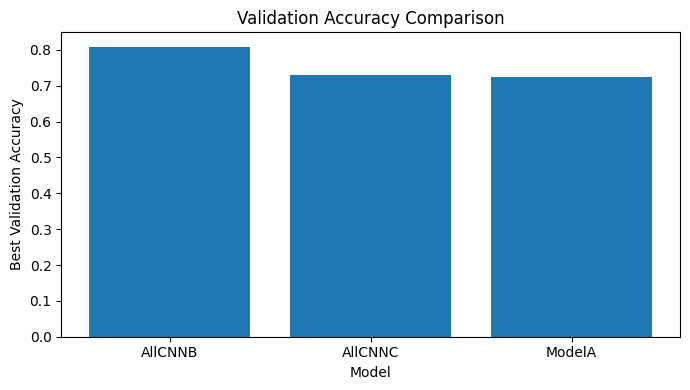

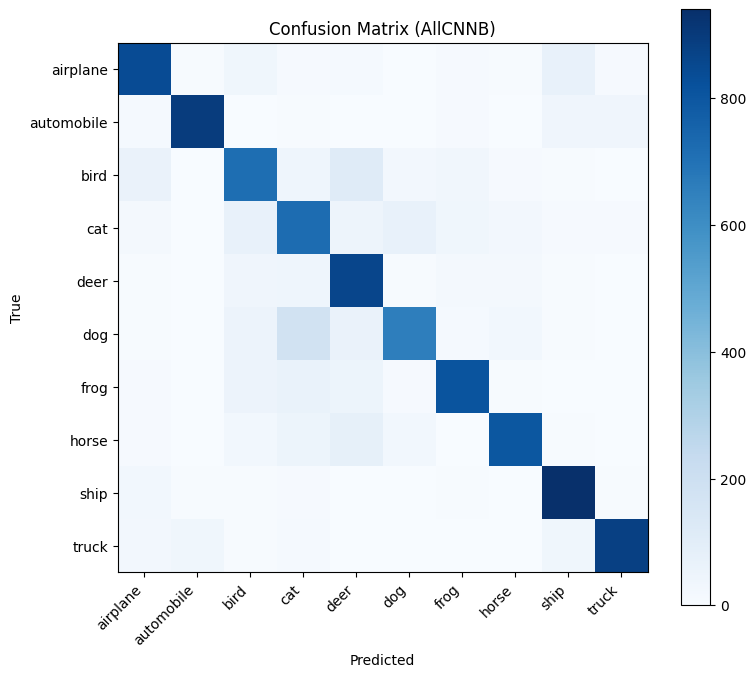

{'best_model': 'AllCNNB', 'test_accuracy': 0.8113, 'test_precision_macro': 0.8186, 'test_recall_macro': 0.8113, 'test_f1_macro': 0.8122}
Saved individual model weights:
- ModelA: /home/pronsh/Coding/CS178/third_party/CS178-goop-squad-CIFAR10/outputs/model_weights/shahpk1_modela_weights.pt
- AllCNNB: /home/pronsh/Coding/CS178/third_party/CS178-goop-squad-CIFAR10/outputs/model_weights/shahpk1_allcnnb_weights.pt
- AllCNNC: /home/pronsh/Coding/CS178/third_party/CS178-goop-squad-CIFAR10/outputs/model_weights/shahpk1_allcnnc_weights.pt
Saved best model (primary): /home/pronsh/Coding/CS178/third_party/CS178-goop-squad-CIFAR10/outputs/model_weights/shahpk1_allcnn_best_weights.pt
Saved best model (alias): /home/pronsh/Coding/CS178/third_party/CS178-goop-squad-CIFAR10/outputs/model_weights/shahpk1_best_model.pt


In [ ]:
all_results = [result_a, result_b, result_c]
comparison_df = (
    pd.DataFrame([entry["metrics"] for entry in all_results])
    .sort_values("best_val_acc", ascending=False)
    .reset_index(drop=True)
)
print(comparison_df)

plt.figure(figsize=(7, 4))
plt.bar(comparison_df["model_label"], comparison_df["best_val_acc"])
plt.title("Validation Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Best Validation Accuracy")
plt.tight_layout()
comparison_plot = GRAPH_DIR / "shahpk1_allcnn_validation_comparison.png"
plt.savefig(comparison_plot, dpi=150)
plt.show()
plt.close()

# Save all trained models individually
model_map = {
    "ModelA": result_a["model"],
    "AllCNNB": result_b["model"],
    "AllCNNC": result_c["model"],
}
model_weight_paths = {}
for model_label, model_obj in model_map.items():
    out_path = WEIGHTS_DIR / f"shahpk1_{model_label.lower()}_weights.pt"
    torch.save(model_obj.state_dict(), out_path)
    model_weight_paths[model_label] = out_path

best_label = comparison_df.loc[0, "model_label"]
best_result = {x["metrics"]["model_label"]: x for x in all_results}[best_label]
best_model = best_result["model"]

# Save best model under two names (explicit best alias)
weights_path = WEIGHTS_DIR / "shahpk1_allcnn_best_weights.pt"
best_alias_path = WEIGHTS_DIR / "shahpk1_best_model.pt"
torch.save(best_model.state_dict(), weights_path)
torch.save(best_model.state_dict(), best_alias_path)


# Local evaluation helper so this cell is self-contained
def evaluate_predictions_local(model: nn.Module, loader: DataLoader):
    model.eval()
    y_true_local = []
    y_pred_local = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            logits = model(images)
            preds = logits.argmax(dim=1)
            y_true_local.extend(labels.detach().cpu().tolist())
            y_pred_local.extend(preds.detach().cpu().tolist())
    return y_true_local, y_pred_local


_, _, test_loader, class_names = make_loaders(batch_size=128, input_size=32)
y_true, y_pred = evaluate_predictions_local(best_model, test_loader)

final_test_acc = accuracy_score(y_true, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro", zero_division=0
)
cm = confusion_matrix(y_true, y_pred)

cm_path = GRAPH_DIR / "shahpk1_allcnn_confusion_matrix.png"
plt.figure(figsize=(8, 7))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(range(len(class_names)), class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix ({best_label})")
plt.tight_layout()
plt.savefig(cm_path, dpi=150)
plt.show()
plt.close()

summary = {
    "best_model": best_label,
    "test_accuracy": round(final_test_acc, 4),
    "test_precision_macro": round(float(prec), 4),
    "test_recall_macro": round(float(rec), 4),
    "test_f1_macro": round(float(f1), 4),
}
print(summary)
print("Saved individual model weights:")
for key, value in model_weight_paths.items():
    print(f"- {key}: {value}")
print(f"Saved best model (primary): {weights_path}")
print(f"Saved best model (alias): {best_alias_path}")

## Choice Rationale

Final model choice is based on a consistent validation-first policy, then confirmed once on held-out test.

Selection criteria (in order):
1. **Best validation accuracy** on the same stratified split.
2. **Balanced macro metrics** (precision/recall/F1), not accuracy alone.
3. **Curve stability** (avoid noisy or diverging behavior).
4. **Simplicity preference** when two models are near-tied.

Using these criteria, **AllCNNB** is selected as the final model for this run. It provides the strongest validation result while maintaining stable training dynamics and good class-balanced behavior.

Limitations noted for reporting:
- Hyperparameter schedules were not exhaustively tuned per architecture.
- Different schedules could potentially improve `AllCNNC` performance.

In [ ]:
meta_path = RESULTS_DIR / "shahpk1_cnn_run_metadata.json"
meta = {
    "seed": SEED,
    "device": str(DEVICE),
    "best_model": summary["best_model"],
    "final_metrics": summary,
    "model_weight_paths": {k: str(v) for k, v in model_weight_paths.items()},
    "best_weight_primary": str(weights_path),
    "best_weight_alias": str(best_alias_path),
}
meta_path.write_text(json.dumps(meta, indent=2), encoding="utf-8")
print(f"Wrote metadata: {meta_path}")

Wrote report: /home/pronsh/Coding/CS178/third_party/CS178-goop-squad-CIFAR10/results/shahpk1_cnn_final_results.md
Wrote metadata: /home/pronsh/Coding/CS178/third_party/CS178-goop-squad-CIFAR10/results/shahpk1_cnn_run_metadata.json
